<a href="https://colab.research.google.com/github/Pranayshukla0610/MLOPS-Project/blob/main/Laptop_Price_Prediction_using_Linear_Regression_with_Advanced_Data_Preprocessing_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import KNNImputer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

In [9]:
class DataIngestion:
    def __init__(self, zip_path, extract_path):
        self.zip_path = zip_path
        self.extract_path = extract_path

    def verify(self):
        if not os.path.exists(self.zip_path):
            raise FileNotFoundError("ZIP file not found")

        with open(self.zip_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        print("Dataset Hash:", file_hash)

    def extract(self):
        os.makedirs(self.extract_path, exist_ok=True)

        with zipfile.ZipFile(self.zip_path, 'r') as zip_ref:
            zip_ref.extractall(self.extract_path)

        print("Extraction Done")

    def load(self):
        files = [f for f in os.listdir(self.extract_path) if f.endswith('.csv')]

        if not files:
            raise FileNotFoundError("No CSV file found after extraction")

        file_path = os.path.join(self.extract_path, files[0])

        # Try multiple encodings (fix for your error)
        encodings = ['utf-8', 'latin1', 'iso-8859-1', 'cp1252']

        for enc in encodings:
            try:
                print(f"Trying encoding: {enc}")
                df = pd.read_csv(file_path, encoding=enc)
                print(f"Loaded successfully with {enc}")
                return df
            except UnicodeDecodeError:
                print(f"Failed with {enc}")

        raise Exception("Could not read the file with available encodings")

In [10]:
ingestion = DataIngestion(
    zip_path = '/content/archive (32).zip',
    extract_path = '/content/data'
)

ingestion.verify()
ingestion.extract()

df = ingestion.load()
print(df.head())

Dataset Hash: d5e71096a3ea585c64577c7331b2bc83
Extraction Done
Trying encoding: utf-8
Failed with utf-8
Trying encoding: latin1
Loaded successfully with latin1
   laptop_ID Company      Product   TypeName  Inches  \
0          1   Apple  MacBook Pro  Ultrabook    13.3   
1          2   Apple  Macbook Air  Ultrabook    13.3   
2          3      HP       250 G6   Notebook    15.6   
3          4   Apple  MacBook Pro  Ultrabook    15.4   
4          5   Apple  MacBook Pro  Ultrabook    13.3   

                     ScreenResolution                         Cpu   Ram  \
0  IPS Panel Retina Display 2560x1600        Intel Core i5 2.3GHz   8GB   
1                            1440x900        Intel Core i5 1.8GHz   8GB   
2                   Full HD 1920x1080  Intel Core i5 7200U 2.5GHz   8GB   
3  IPS Panel Retina Display 2880x1800        Intel Core i7 2.7GHz  16GB   
4  IPS Panel Retina Display 2560x1600        Intel Core i5 3.1GHz   8GB   

                Memory                           Gpu

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [13]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


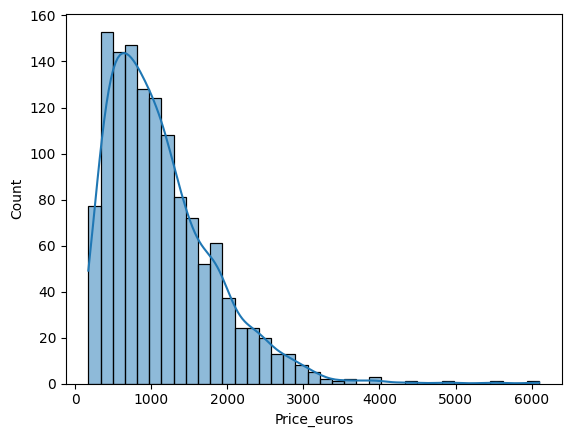

In [15]:
sns.histplot(df['Price_euros'], kde = True)
plt.show()

In [16]:
print("Skew:",df['Price_euros'].skew())

Skew: 1.5208655681688525


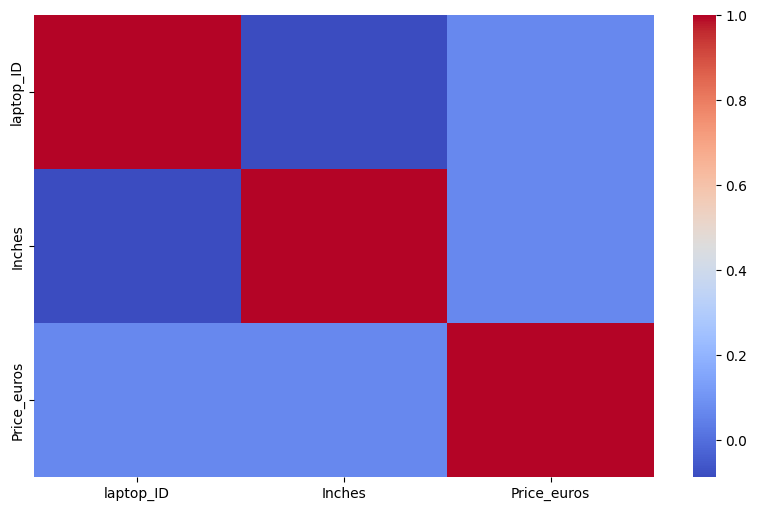

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm')
plt.show()

In [22]:
df['Ram'] = (
    df['Ram']
    .astype(str)
    .str.extract(r'(\d+)')[0]   # extract only numbers
    .astype(float)
)

df['Weight'] = (
    df['Weight']
    .astype(str)
    .str.extract(r'([\d.]+)')[0]  # extract decimal numbers
    .astype(float)
)

In [23]:
imputer = KNNImputer(n_neighbors=5)
num_cols = df.select_dtypes(include = np.number).columns
df[num_cols] = imputer.fit_transform(df[num_cols])

In [24]:
df = pd.get_dummies(df, drop_first=True)

In [25]:
df.head()

,laptop_ID,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,...,Gpu_Nvidia Quadro M620,Gpu_Nvidia Quadro M620M,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS
0,1.0,13.3,8.0,1.37,1339.69,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2.0,13.3,8.0,1.34,898.94,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,3.0,15.6,8.0,1.86,575.00,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4.0,15.4,16.0,1.83,2537.45,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,5.0,13.3,8.0,1.37,1803.60,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [27]:
df['Price_log'] = np.log1p(df['Price_euros'])
df['Ram_per_weight'] = df['Ram']/df['Weight']

In [28]:
df.head()

,laptop_ID,Inches,Ram,Weight,Price_euros,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,...,OpSys_Chrome OS,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,Price_log,Ram_per_weight
0,1.0,13.3,8.0,1.37,1339.69,True,False,False,False,False,...,False,False,False,False,False,False,False,True,7.200940,5.839416
1,2.0,13.3,8.0,1.34,898.94,True,False,False,False,False,...,False,False,False,False,False,False,False,True,6.802328,5.970149
2,3.0,15.6,8.0,1.86,575.00,False,False,False,False,False,...,False,False,False,True,False,False,False,False,6.356108,4.301075
3,4.0,15.4,16.0,1.83,2537.45,True,False,False,False,False,...,False,False,False,False,False,False,False,True,7.839309,8.743169
4,5.0,13.3,8.0,1.37,1803.60,True,False,False,False,False,...,False,False,False,False,False,False,False,True,7.498094,5.839416


In [29]:
X = df.drop(['Price_euros','Price_log'], axis=1)
y = df['Price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# 1. Convert categorical → numeric
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# 2. Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 3. FORCE everything to numeric
X_train = X_train.apply(pd.to_numeric, errors='coerce')
y_train = pd.to_numeric(y_train, errors='coerce')

# 4. Drop rows with NaN (VERY IMPORTANT)
combined = pd.concat([X_train, y_train], axis=1).dropna()

X_train = combined.drop(columns=[y_train.name])
y_train = combined[y_train.name]

# 5. Convert to float explicitly (CRITICAL FIX)
X_train = X_train.astype(float)
y_train = y_train.astype(float)

# 6. Add constant
import statsmodels.api as sm
X_const = sm.add_constant(X_train)

# 7. Train model
model = sm.OLS(y_train, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Price_log   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     50.02
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          9.97e-201
Time:                        07:05:18   Log-Likelihood:                 1437.5
No. Observations:                1042   AIC:                            -1459.
Df Residuals:                     334   BIC:                             2045.
Df Model:                         707                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

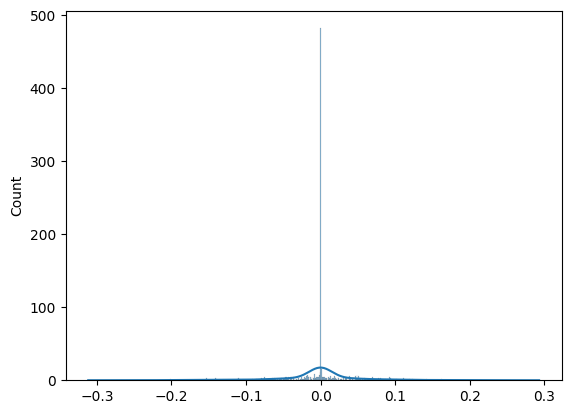

In [43]:
residuals = model.resid
sns.histplot(residuals, kde=True)
plt.show()

In [44]:
print("Breusch-Pagan Test:", het_breuschpagan(residuals, X_const))

Breusch-Pagan Test: (np.float64(677.3784863216703), np.float64(0.9999999999994115), np.float64(0.8776395025720257), np.float64(0.9208755373853865))


In [45]:
print("Durbin Watson:", durbin_watson(residuals))

Durbin Watson: 1.9582676315260388


In [46]:
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', Ridge(alpha=1.0))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', RobustScaler()), ('model', Ridge())])

In [47]:
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.1826067864959528
R2: 0.9056754548964334


In [48]:
import joblib
joblib.dump(pipeline, "model.pkl")

['model.pkl']

In [49]:
def predict(input_df):
    model = joblib.load("model.pkl")
    return model.predict(input_df)